In [11]:
import statsmodels.api as sm

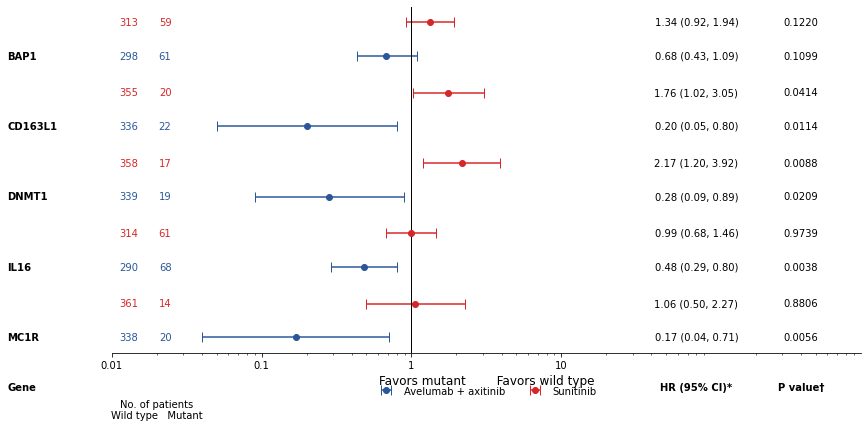

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. データの準備 (画像の構造を模したダミーデータ)
data = {
    'Gene': ['BAP1', 'CD163L1', 'DNMT1', 'IL16', 'MC1R'],
    # Avelumab + axitinib (Blue)
    'HR_A': [0.68, 0.20, 0.28, 0.48, 0.17],
    'CI_L_A': [0.43, 0.05, 0.09, 0.29, 0.04],
    'CI_U_A': [1.09, 0.80, 0.89, 0.80, 0.71],
    'P_A': [0.1099, 0.0114, 0.0209, 0.0038, 0.0056],
    'N_WT_A': [298, 336, 339, 290, 338], # Wild type count
    'N_Mut_A': [61, 22, 19, 68, 20],     # Mutant count
    # Sunitinib (Red)
    'HR_S': [1.34, 1.76, 2.17, 0.99, 1.06],
    'CI_L_S': [0.92, 1.02, 1.20, 0.68, 0.50],
    'CI_U_S': [1.94, 3.05, 3.92, 1.46, 2.27],
    'P_S': [0.1220, 0.0414, 0.0088, 0.9739, 0.8806],
    'N_WT_S': [313, 355, 358, 314, 361],
    'N_Mut_S': [59, 20, 17, 61, 14],
}
df = pd.DataFrame(data)

# 2. プロットの設定
fig, ax = plt.subplots(figsize=(12, 6))

# Y軸の位置設定（遺伝子ごとにスペースを空ける）
y_base = np.arange(len(df)) * 2.5  # 遺伝子間の間隔
y_shift = 0.6  # 青と赤のバーの距離

# 色の設定
col_blue = '#2b579a' # 画像に近い青
col_red = '#d62728'  # 画像に近い赤

# 3. データの描画ループ
for i, row in df.iterrows():
    y = y_base[i]
    
    # --- Avelumab (Blue) の描画 ---
    # エラーバー (xerrは [中心-下限, 上限-中心] の形にする)
    err_low_A = row['HR_A'] - row['CI_L_A']
    err_high_A = row['CI_U_A'] - row['HR_A']
    
    ax.errorbar(row['HR_A'], y + y_shift, xerr=[[err_low_A], [err_high_A]], 
                fmt='o', color=col_blue, capsize=5, label='Avelumab + axitinib' if i==0 else "")
    
    # --- Sunitinib (Red) の描画 ---
    err_low_S = row['HR_S'] - row['CI_L_S']
    err_high_S = row['CI_U_S'] - row['HR_S']
    
    ax.errorbar(row['HR_S'], y - y_shift, xerr=[[err_low_S], [err_high_S]], 
                fmt='o', color=col_red, capsize=5, label='Sunitinib' if i==0 else "")

    # --- テキスト情報の追加 (表の部分) ---
    # 左側のテキスト (Gene名, 人数)
    ax.text(0.002, y + y_shift, row['Gene'], ha='left', va='center', fontweight='bold')
    
    # 人数 (青)
    ax.text(0.015, y + y_shift, f"{row['N_WT_A']}", ha='right', va='center', color=col_blue)
    ax.text(0.025, y + y_shift, f"{row['N_Mut_A']}", ha='right', va='center', color=col_blue)
    # 人数 (赤)
    ax.text(0.015, y - y_shift, f"{row['N_WT_S']}", ha='right', va='center', color=col_red)
    ax.text(0.025, y - y_shift, f"{row['N_Mut_S']}", ha='right', va='center', color=col_red)

    # 右側のテキスト (HR, P値)
    # 文字列整形: "0.68 (0.43, 1.09)" の形
    text_HR_A = f"{row['HR_A']:.2f} ({row['CI_L_A']:.2f}, {row['CI_U_A']:.2f})"
    text_HR_S = f"{row['HR_S']:.2f} ({row['CI_L_S']:.2f}, {row['CI_U_S']:.2f})"
    
    # 青の数値
    ax.text(80, y + y_shift, text_HR_A, ha='center', va='center')
    ax.text(400, y + y_shift, f"{row['P_A']:.4f}", ha='center', va='center')
    # 赤の数値
    ax.text(80, y - y_shift, text_HR_S, ha='center', va='center')
    ax.text(400, y - y_shift, f"{row['P_S']:.4f}", ha='center', va='center')

# 4. 軸とレイアウトの調整
# 対数スケールに設定
ax.set_xscale('log')
ax.set_xlim(0.01, 1000) # テキストスペース確保のため広く取る

# グラフ中央の基準線 (HR=1)
ax.axvline(1, color='black', linestyle='-', linewidth=1)

# 軸ラベルと目盛りの設定
ax.set_yticks([]) # Y軸の目盛りを消す
ax.set_xlabel('Favors mutant        Favors wild type', fontsize=12)

# X軸の目盛りを画像に合わせて手動設定
xticks = [0.01, 0.1, 1, 10]
ax.set_xticks(xticks)
ax.set_xticklabels(xticks)

# グラフの枠線を消してスッキリさせる (上の枠と右の枠)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# ヘッダー情報の追加 (手動配置)
ax.text(0.002, y_base[-1] + 2.5, "Gene", fontweight='bold')
ax.text(0.02, y_base[-1] + 3.5, "No. of patients\nWild type   Mutant", ha='center')
ax.text(80, y_base[-1] + 2.5, "HR (95% CI)*", ha='center', fontweight='bold')
ax.text(400, y_base[-1] + 2.5, "P value†", ha='center', fontweight='bold')

# 凡例
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Y軸を反転（上から順に表示するため）
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [2]:
df

,Gene,HR_A,CI_L_A,CI_U_A,P_A,N_WT_A,N_Mut_A,HR_S,CI_L_S,CI_U_S,P_S,N_WT_S,N_Mut_S
0,BAP1,0.68,0.43,1.09,0.1099,298,61,1.34,0.92,1.94,0.1220,313,59
1,CD163L1,0.20,0.05,0.80,0.0114,336,22,1.76,1.02,3.05,0.0414,355,20
2,DNMT1,0.28,0.09,0.89,0.0209,339,19,2.17,1.20,3.92,0.0088,358,17
3,IL16,0.48,0.29,0.80,0.0038,290,68,0.99,0.68,1.46,0.9739,314,61
4,MC1R,0.17,0.04,0.71,0.0056,338,20,1.06,0.50,2.27,0.8806,361,14


In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. データの準備 (High, Middle, Low の3つのDataFrameがあると仮定)
# ここではダミーデータを作成します
np.random.seed(42)
def create_dummy_data(n):
    return pd.DataFrame({
        'SAS': np.random.randint(0, 2, n), # 目的変数 (0 or 1)
        'METs_cat': np.random.choice(['Q1', 'Q2', 'Q3', 'Q4'], n), # 説明変数
        'Age': np.random.randint(40, 70, n),
        'Sex': np.random.randint(0, 2, n)
    })

High = create_dummy_data(300)
Middle = create_dummy_data(300)
Low = create_dummy_data(300)

# 2. ロジスティック回帰を実行し、結果を抽出する関数
def run_logistic_and_extract(df, group_name):
    # SAS有無を METsカテゴリー(Q1基準) + 年齢 + 性別 で調整する場合
    formula = "SAS ~ C(METs_cat, Treatment(reference='Q1')) + Age + Sex"
    model = smf.logit(formula, data=df).fit(disp=0)
    
    # オッズ比と信頼区間を取得
    odds_ratios = np.exp(model.params)
    conf = np.exp(model.conf_int())
    conf.columns = ['Lower', 'Upper']
    p_values = model.pvalues
    
    # 結果をまとめる
    results = []
    # 興味のある変数だけ抽出 (METs_cat の Q2, Q3, Q4)
    target_vars = [v for v in model.params.index if 'METs_cat' in v]
    
    for var in target_vars:
        # 変数名からラベルを綺麗にする (例: C(METs_cat...)[T.Q2] -> Q2)
        label = var.split('[T.')[1].replace(']', '')
        results.append({
            'Group': group_name,
            'Category': label,
            'OR': odds_ratios[var],
            'Lower': conf.loc[var, 'Lower'],
            'Upper': conf.loc[var, 'Upper'],
            'P_val': p_values[var]
        })
    return pd.DataFrame(results)

# 3. 3つのグループで実行して結合
res_high = run_logistic_and_extract(High, 'High')
res_middle = run_logistic_and_extract(Middle, 'Middle')
res_low = run_logistic_and_extract(Low, 'Low')

# 全データを結合
plot_data = pd.concat([res_high, res_middle, res_low], ignore_index=True)

print(plot_data)

    Group Category        OR     Lower     Upper     P_val
0    High       Q2  0.877657  0.448113  1.718944  0.703576
1    High       Q3  1.237242  0.630905  2.426305  0.535565
2    High       Q4  1.053447  0.561713  1.975657  0.871080
3  Middle       Q2  1.111598  0.578166  2.137187  0.751080
4  Middle       Q3  1.412837  0.749613  2.662853  0.285188
5  Middle       Q4  1.165017  0.598511  2.267738  0.653105
6     Low       Q2  0.549576  0.292780  1.031606  0.062446
7     Low       Q3  0.603697  0.314916  1.157295  0.128514
8     Low       Q4  0.490056  0.254976  0.941872  0.032386


In [6]:
plot_data

,Group,Category,OR,Lower,Upper,P_val
0,High,Q2,0.877657,0.448113,1.718944,0.703576
1,High,Q3,1.237242,0.630905,2.426305,0.535565
2,High,Q4,1.053447,0.561713,1.975657,0.871080
3,Middle,Q2,1.111598,0.578166,2.137187,0.751080
4,Middle,Q3,1.412837,0.749613,2.662853,0.285188
5,Middle,Q4,1.165017,0.598511,2.267738,0.653105
6,Low,Q2,0.549576,0.292780,1.031606,0.062446
7,Low,Q3,0.603697,0.314916,1.157295,0.128514
8,Low,Q4,0.490056,0.254976,0.941872,0.032386


In [12]:
# Demo Data
import pandas as pd
import numpy as np

# 再現性のためシードを固定
np.random.seed(42)

def create_categorical_demo_data(n=300):
    """
    指定された行数のダミーデータを作成する関数
    """
    df = pd.DataFrame({
        # 1. Binary Data (0 or 1)
        'Target': np.random.randint(0, 2, n),
        'SAS_Flag': np.random.randint(0, 2, n),
        
        # 2. Categorical Data
        # AgeGroup: 年代カテゴリー
        'AgeGroup': np.random.choice(['40-49', '50-59', '60-69', '70+'], n, p=[0.2, 0.3, 0.3, 0.2]),
        
        # Townsend_Cat: タウンゼント剥奪指数のカテゴリー (Q1:裕福 ~ Q4:貧困)
        'Townsend_Cat': np.random.choice(['Q1', 'Q2', 'Q3', 'Q4'], n),
        
        # METs_Cat: 身体活動レベル (Low, Moderate, High)
        'METs_Cat': np.random.choice(['Low', 'Moderate', 'High'], n, p=[0.4, 0.4, 0.2])
    })
    return df

# --- 3つのDataFrameを作成 ---
DF_High = create_categorical_demo_data(300)   # High PRS Group
DF_Middle = create_categorical_demo_data(300) # Middle PRS Group
DF_Low = create_categorical_demo_data(300)    # Low PRS Group

# 結果の確認 (DF_Highの先頭5行)
print("--- DF_High Head ---")
print(DF_High.head())

print("\n--- データ型 (Dtypes) ---")
print(DF_High.dtypes)

--- DF_High Head ---
   Target  SAS_Flag AgeGroup Townsend_Cat  METs_Cat
0       0         0    40-49           Q1       Low
1       1         0    60-69           Q2      High
2       0         0    60-69           Q4  Moderate
3       0         1    60-69           Q2       Low
4       0         1    60-69           Q1       Low

--- データ型 (Dtypes) ---
Target           int64
SAS_Flag         int64
AgeGroup        object
Townsend_Cat    object
METs_Cat        object
dtype: object


In [13]:
DF_High

,Target,SAS_Flag,AgeGroup,Townsend_Cat,METs_Cat
0,0,0,40-49,Q1,Low
1,1,0,60-69,Q2,High
2,0,0,60-69,Q4,Moderate
3,0,1,60-69,Q2,Low
4,0,1,60-69,Q1,Low
...,...,...,...,...,...
295,1,1,50-59,Q1,Moderate
296,1,0,60-69,Q4,Low
297,0,0,40-49,Q4,Low
298,0,1,40-49,Q3,High


In [213]:
import statsmodels.stats.multitest as smm

class LogiticRegression:
    def __init__(self, df): 

        if df.empty:
            raise ValueError("入力されたDataFrameが空です。")
        self.df = df

    """
    Categoryデータに関しては、変数をLevel0~4のようにRefが0となるような順番にコーディングすること: 
    """

    def logistic_regression_creator(self,continuous_col,categorical_col,target_col):
        
        sample_df = self.df[target_col+continuous_col+categorical_col]
        
        features = []
        features.extend(continuous_col)

        for col in categorical_col:
            features.append(f'C({col}, Treatment(reference=0))')

        formula = f'{target_col} ~ {" + ".join(features)}'
        print(f"Generated Formula: {formula}")

        model = sm.logit(formula = formula, data = sample_df)
        result = model.fit()

        result = model.fit()
        ci_exp = np.exp(result.conf_int())
        
        # ここからOrganizeしていく
        df_result = pd.DataFrame({
        'ORs': np.exp(result.params),
        'Coef (係数)': result.params,
        'P-value': result.pvalues,
        'CI_Upper':ci_exp[1],
        'CI_Lower':ci_exp[0],
        'Std.Err': result.bse
    
        })


        return ci_exp,df_result 


    """
    Formulaを事前に指定していれるVersion 
    """


    def logistic_regression_formula(self,formula):


        model = sm.Logit.from_formula(formula, data=self.df)
        result = model.fit()
        ci_exp = np.exp(result.conf_int())
        
        # ここからOrganizeしていく
        df_result = pd.DataFrame({
        'ORs': np.exp(result.params),
        'Coef (係数)': result.params,
        'P-value': result.pvalues,
        'CI_Upper':ci_exp[1],
        'CI_Lower':ci_exp[0],
        'Std.Err': result.bse
    
        })
        return df_result
    
    """
    Logistic RegressiongあとのDataFrame作成
    """


    def result_show(self,result):


        res = []
        for i in range(len(result)):
            r = result.iloc[i:i+1]
            index_name = r.index[0]

            if index_name == 'Intercept':
                continue

            find = re.findall(pattern, index_name)
            # res.append({'Variable': find[0][0],
            #             'Category': find[0][2],
            #             'Treatment': find[0][1],
            #             'ORs': r['ORs'].values[0],
            #             'CI_Lower': r['CI_Lower'].values[0],
            #             'CI_Upper': r['CI_Upper'].values[0],
            #             'P-value': r['P-value'].values[0]
            #             })
            ors_val = r['ORs'].values[0]
            lower_val = r['CI_Lower'].values[0]
            upper_val = r['CI_Upper'].values[0]
            p_val = r['P-value'].values[0]

            # P値の整形ロジック
            if p_val < 0.001:
                p_str = '< 0.001'
            else:
                p_str = f'{p_val:.3f}'

            
            res.append({
            'Variable': find[0][0],
            'Category': find[0][2],
            'Treatment': find[0][1],
            
            # :.3f をつけることで小数点3桁に固定
            # 形: "1.234 [0.900-1.500]"
            'ORs': f'{ors_val:.3f} [{lower_val:.3f}-{upper_val:.3f}]',
            'Odds': ors_val,
            'CI_Lower': lower_val,
            'CI_Upper': upper_val,
            # P値も同様に3桁にする場合
            'P-value': p_str
            })

        data = pd.DataFrame(res)

        """
        Bonferroni 
        """
        data['P-value']=pd.to_numeric(data['P-value'], errors='coerce')
        p_values = data['P-value']


        corrected_result = smm.multipletests(p_values, alpha=0.05, method='bonferroni')
        pval = corrected_result[1]
        data['Bonferroni_P-value'] = pval
        

        """
        Holm 
        """
        corrected_result = smm.multipletests(p_values, alpha=0.05, method='bonferroni')
        pval = corrected_result[1]

        data['Holm_P-value']=pval

        return data

In [219]:
Logistic = LogiticRegression(DF_High)
result = Logistic.logistic_regression_formula('SAS_Flag ~ C(METs_Cat, Treatment(reference="Low")) + C(AgeGroup, Treatment(reference="40-49")) + C(Townsend_Cat, Treatment(reference="Q1"))')
data_1 = Logistic.result_show(result)
data_1['Group']='High'

data_2 = Logistic.result_show(result)
data_2['Group']='Low'

Optimization terminated successfully.
         Current function value: 0.681834
         Iterations 4


In [220]:
data_1,data_2

(       Variable  Category Treatment                  ORs      Odds  CI_Lower  \
 0      METs_Cat      High       Low  1.133 [0.602-2.132]  1.132530  0.601535   
 1      METs_Cat  Moderate       Low  1.276 [0.760-2.144]  1.276268  0.759637   
 2      AgeGroup     50-59     40-49  0.904 [0.466-1.755]  0.904065  0.465705   
 3      AgeGroup     60-69     40-49  0.941 [0.494-1.791]  0.940913  0.494440   
 4      AgeGroup       70+     40-49  1.193 [0.599-2.376]  1.193071  0.598994   
 5  Townsend_Cat        Q2        Q1  1.115 [0.593-2.095]  1.114616  0.593061   
 6  Townsend_Cat        Q3        Q1  1.046 [0.547-2.002]  1.046274  0.546864   
 7  Townsend_Cat        Q4        Q1  0.678 [0.343-1.338]  0.677876  0.343311   
 
    CI_Upper  P-value  Bonferroni_P-value  Holm_P-value Group  
 0  2.132250    0.700                 1.0           1.0  High  
 1  2.144261    0.357                 1.0           1.0  High  
 2  1.755045    0.766                 1.0           1.0  High  
 3  1.790545 

In [146]:
import re

In [165]:
res = []
for i in range(len(result)):
    r = result.iloc[i:i+1]
    index_name = r.index[0]
    if index_name == 'Intercept':
        continue

    find = re.findall(pattern, index_name)
    # res.append({'Variable': find[0][0],
    #             'Category': find[0][2],
    #             'Treatment': find[0][1],
    #             'ORs': r['ORs'].values[0],
    #             'CI_Lower': r['CI_Lower'].values[0],
    #             'CI_Upper': r['CI_Upper'].values[0],
    #             'P-value': r['P-value'].values[0]
    #             })
    ors_val = r['ORs'].values[0]
    lower_val = r['CI_Lower'].values[0]
    upper_val = r['CI_Upper'].values[0]
    p_val = r['P-value'].values[0]

    # P値の整形ロジック
    if p_val < 0.001:
        p_str = '< 0.001'
    else:
        p_str = f'{p_val:.3f}'

    
    res.append({
    'Variable': find[0][0],
    'Category': find[0][2],
    'Treatment': find[0][1],
    
    # :.3f をつけることで小数点3桁に固定
    # 形: "1.234 [0.900-1.500]"
    'ORs': f'{ors_val:.3f} [{lower_val:.3f}-{upper_val:.3f}]',
    
    # P値も同様に3桁にする場合
    'P-value': p_str
    })

data = pd.DataFrame(res)

In [166]:
data

,Variable,Category,Treatment,ORs,P-value
0,METs_Cat,High,Low,1.133 [0.602-2.132],0.700
1,METs_Cat,Moderate,Low,1.276 [0.760-2.144],0.357
2,AgeGroup,50-59,40-49,0.904 [0.466-1.755],0.766
3,AgeGroup,60-69,40-49,0.941 [0.494-1.791],0.853
4,AgeGroup,70+,40-49,1.193 [0.599-2.376],0.616
5,Townsend_Cat,Q2,Q1,1.115 [0.593-2.095],0.736
6,Townsend_Cat,Q3,Q1,1.046 [0.547-2.002],0.891
7,Townsend_Cat,Q4,Q1,0.678 [0.343-1.338],0.263


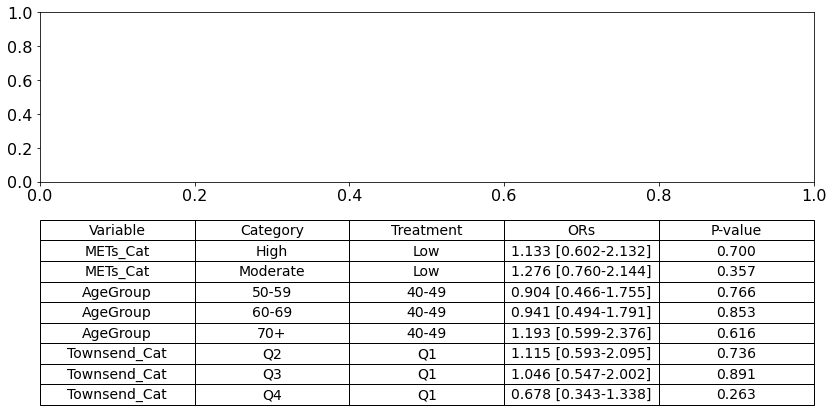

In [164]:
fig, ax = plt.subplots(2,1,figsize=(12, 6))
ax[1].axis('off')
ax[1].axis('tight')

# テーブルの作成
# cellText: 表の中身 (df.values)
# colLabels: 列名 (df.columns)
# loc: 配置位置
table = ax[1].table(
    cellText=data.values,
    colLabels=data.columns,
    loc='center',
    cellLoc='center' # セル内の文字を中央揃え
)

# 【オプション】テーブルの見栄え調整
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 1.5) # (横のスケール, 縦のスケール) で行の高さを広げる

plt.tight_layout()
plt.show()

In [ ]:
# Groupごとに特定の変数のtableを出して、その横か何かにForestPlotを描けばわかりやすいか
fig, ax = plt.subplots(1,1,figsize=(6, 4)

# Plotting Forestplot 

In [232]:
df = pd.concat([data_1,data_2],axis=0)
df

,Variable,Category,Treatment,ORs,Odds,CI_Lower,CI_Upper,P-value,Bonferroni_P-value,Holm_P-value,Group
0,METs_Cat,High,Low,1.133 [0.602-2.132],1.132530,0.601535,2.132250,0.700,1.0,1.0,High
1,METs_Cat,Moderate,Low,1.276 [0.760-2.144],1.276268,0.759637,2.144261,0.357,1.0,1.0,High
2,AgeGroup,50-59,40-49,0.904 [0.466-1.755],0.904065,0.465705,1.755045,0.766,1.0,1.0,High
3,AgeGroup,60-69,40-49,0.941 [0.494-1.791],0.940913,0.494440,1.790545,0.853,1.0,1.0,High
4,AgeGroup,70+,40-49,1.193 [0.599-2.376],1.193071,0.598994,2.376348,0.616,1.0,1.0,High
5,Townsend_Cat,Q2,Q1,1.115 [0.593-2.095],1.114616,0.593061,2.094841,0.736,1.0,1.0,High
6,Townsend_Cat,Q3,Q1,1.046 [0.547-2.002],1.046274,0.546864,2.001757,0.891,1.0,1.0,High
7,Townsend_Cat,Q4,Q1,0.678 [0.343-1.338],0.677876,0.343311,1.338483,0.263,1.0,1.0,High
0,METs_Cat,High,Low,1.133 [0.602-2.132],1.132530,0.601535,2.132250,0.700,1.0,1.0,Low
1,METs_Cat,Moderate,Low,1.276 [0.760-2.144],1.276268,0.759637,2.144261,0.357,1.0,1.0,Low


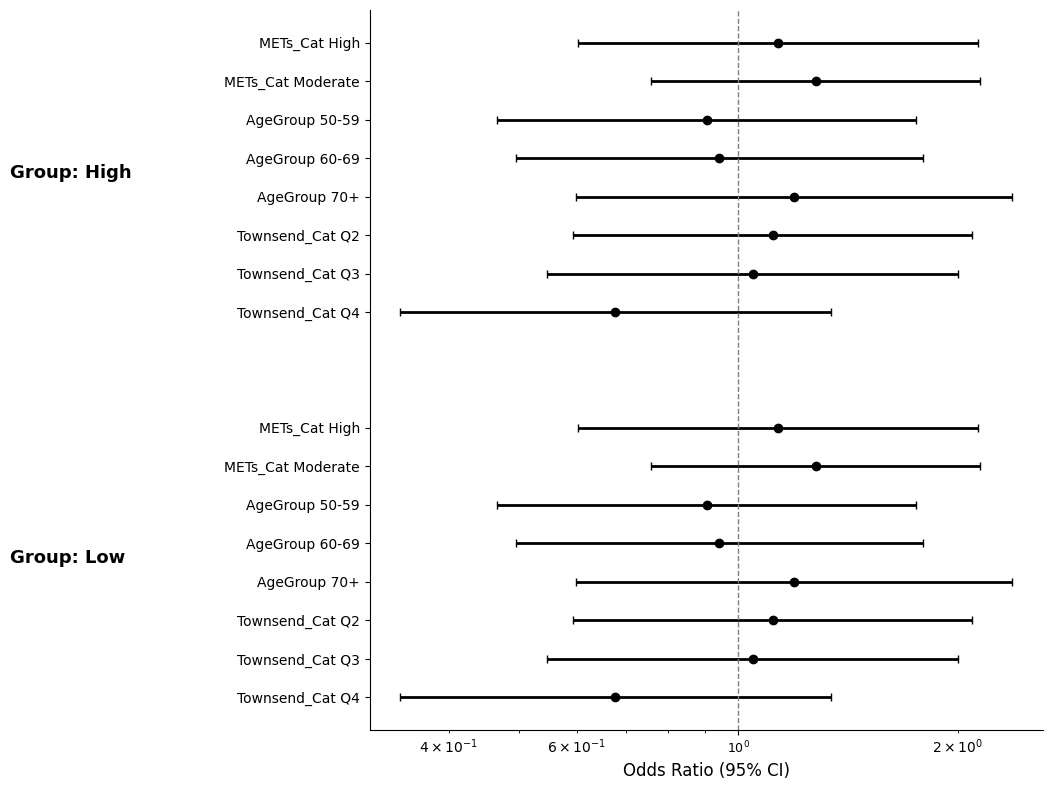

In [238]:
plt.style.use("default")
fig, ax = plt.subplots(figsize=(12, 8))

# ============================
# ③ グループごとにプロット位置を決定
# ============================
df["Label"] = df["Variable"] + " " + df["Category"]
df_high = df[df["Group"] == "High"]
df_low  = df[df["Group"] == "Low"]

# High 上段
y_high = np.arange(len(df_high))[::-1] + len(df_low) + 2  
# Low 下段
y_low = np.arange(len(df_low))[::-1]

# ============================
# ④ プロット関数（Natureスタイル）
# ============================
def plot_forest(ax, df_sub, y):
    ax.errorbar(
        df_sub["Odds"], y,
        xerr=[df_sub["Odds"] - df_sub["CI_Lower"], df_sub["CI_Upper"] - df_sub["Odds"]],
        fmt='o',
        ecolor='black',
        elinewidth=2,
        capsize=3,
        markersize=6,
        markerfacecolor='black',
        markeredgecolor='black'
    )

# High / Low 描画
plot_forest(ax, df_high, y_high)
plot_forest(ax, df_low, y_low)

# ============================
# ⑤ 装飾
# ============================
all_y = np.concatenate([y_high, y_low])
all_labels = pd.concat([df_high, df_low])["Label"]

ax.set_xscale("log")
ax.axvline(1.0, color='grey', linestyle='--', linewidth=1)

ax.set_yticks(all_y)
ax.set_yticklabels(all_labels, fontsize=10)

ax.set_xlabel("Odds Ratio (95% CI)", fontsize=12)
ax.tick_params(axis='x', labelsize=9)

# タイトル（任意）
ax.text(0.1, y_high.mean(), "Group: High", fontsize=13, fontweight="bold")
ax.text(0.1, y_low.mean(),  "Group: Low", fontsize=13, fontweight="bold")

# スパイン削除（Nature風）
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()